In [1]:
!pip install river

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 63.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Balance QR Dataset

In [2]:
import pandas as pd

df_word = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/Word_Top10_Features.csv")
df_excel = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/Excel_Top10_Features.csv")
df_pdf = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/PDF_Top10_features.csv")
df_html = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/HTML_Top13_Features.csv")
df_qr_benign = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_benign.csv")
df_qr_malicious = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_malicious.csv")

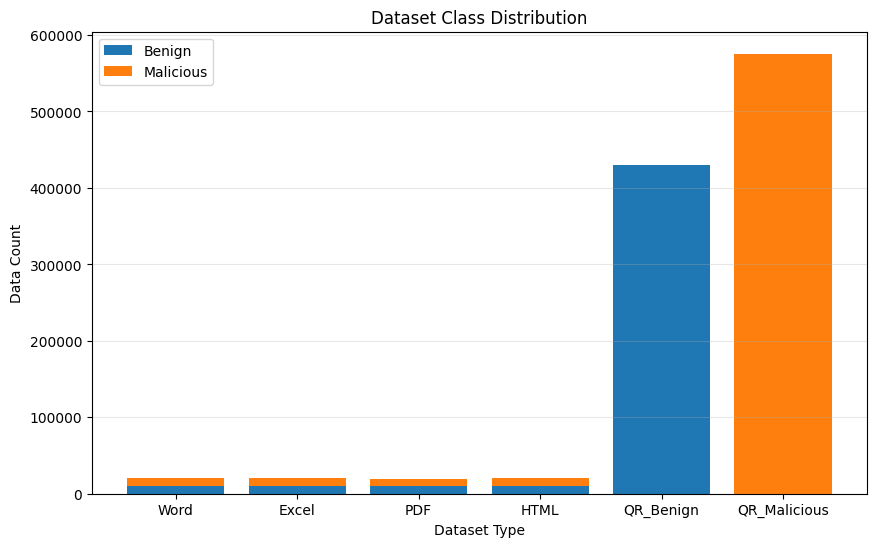

In [8]:
import matplotlib.pyplot as plt

df_qr_benign["label"] = 0
df_qr_malicious["label"] = 1

datasets = {
    "Word": df_word,
    "Excel": df_excel,
    "PDF": df_pdf,
    "HTML": df_html,
    "QR_Benign": df_qr_benign,
    "QR_Malicious": df_qr_malicious
}


benign_counts = []
malicious_counts = []
names = []

for name, df in datasets.items():
    names.append(name)
    benign_counts.append((df["label"] == 0).sum())
    malicious_counts.append((df["label"] == 1).sum())

x = range(len(names))

plt.figure(figsize=(10,6))

plt.bar(x, benign_counts, label="Benign")
plt.bar(x, malicious_counts, bottom=benign_counts, label="Malicious")

plt.xticks(x, names)
plt.title("Dataset Class Distribution")
plt.xlabel("Dataset Type")
plt.ylabel("Data Count")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [4]:
df_word.head()

,file_name,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,label
0,benign_000000,0,0,0,1,0,6.826819,12,10,27585,11,0
1,benign_000001,0,0,0,1,0,7.389457,14,11,36658,10,0
2,benign_000002,0,0,0,1,0,6.850923,12,10,28887,11,0
3,benign_000003,0,0,0,1,0,7.408635,14,11,39295,10,0
4,benign_000004,0,0,0,1,0,7.388929,14,11,36659,10,0


In [5]:
df_word.count()

,0
file_name,20000
ole_object_count,20000
ole_object_type_count,20000
macro_present,20000
dde_present,20000
vba_keywords_count,20000
entropy,20000
struct_ContentType,20000
struct_PartName,20000
file_size,20000


In [6]:
df_excel.head()

,file_name,entropy_of_text,macro_chr_count,macro_vocab_size,macro_arithmetic_operator_count,macro_token_count,macro_max_line_length,remote_template_present,numeric_cell_count,string_cell_count,avg_cell_length,label
0,benign_sample_3253.xlsx,5.746068,39,10079,4759,10079,38,1,4336,8926,11.184588,0
1,benign_sample_5685.xlsx,5.749956,287,19789,28783,19789,42,1,27138,54355,11.167818,0
2,benign_sample_8732.xlsx,5.745470,122,16084,12754,16084,38,1,12033,23997,11.132195,0
3,benign_sample_5743.xlsx,5.743675,152,17382,16244,17382,39,1,15217,30554,11.104673,0
4,benign_sample_5522.xlsx,5.748130,106,15452,11529,15452,38,1,10837,21622,11.151976,0


In [7]:
df_excel.count()

,0
file_name,20000
entropy_of_text,20000
macro_chr_count,20000
macro_vocab_size,20000
macro_arithmetic_operator_count,20000
macro_token_count,20000
macro_max_line_length,20000
remote_template_present,20000
numeric_cell_count,20000
string_cell_count,20000


In [ ]:
df_pdf.head()

,text_length,total_filters,title_chars,file_size,object_count,stream_count,endstream_count,metadata_size,valid_pdf_header,entropy_of_streams,label
0,8018,8,8,20362,120,18,9,254,1,6.010192,0
1,11568,7,35,28848,36,16,8,242,1,6.240051,0
2,1377,2,12,76563,21,4,2,138,1,5.830408,0
3,30607,11,8,67982,46,26,13,278,1,6.317049,0
4,1,2,37,3997,10,6,3,156,1,5.442597,1


In [ ]:
df_pdf.count()

,0
text_length,19296
total_filters,19296
title_chars,19296
file_size,19296
object_count,19296
stream_count,19296
endstream_count,19296
metadata_size,19296
valid_pdf_header,19296
entropy_of_streams,19296


In [ ]:
df_html.head()

,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label
0,sample_09001.html,756,475,0.476933,5.072891,0,11,0.152737,4.906402,1,57,15762,39,109,0
1,sample_09002.html,287,82,0.356557,5.202024,0,3,0.179456,4.625064,21,8,2543,27,130,0
2,sample_09003.html,667,406,0.390225,5.164168,1,10,0.149810,4.220362,9,80,7163,26,333,0
3,sample_09004.html,1204,321,0.534781,5.671159,0,33,0.025707,5.626662,17,74,268250,2,1013,0
4,sample_09005.html,2606,665,0.441595,5.136624,5,8,0.130050,5.462992,8,243,7666,8,924,0


In [ ]:
df_html.count()

,0
file_name,19997
url_punct_char_count,19997
tag_count,19997
whitespace_ratio,19997
entropy,19997
form_count,19997
embedded_js_count,19997
html_whitespace_ratio,19997
script_entropy,19997
min_link_length,19997


In [ ]:
df_qr_benign.head()

,index,url,qr_path,label
0,1,http://freshrpms.net/,Output\QR_All_benign\qrs\benign_000001.png,0
1,2,http://lists.freshrpms.net/mailman/listinfo/rp...,Output\QR_All_benign\qrs\benign_000002.png,0
2,3,http://www.boquist.net/stort-sup-brev,Output\QR_All_benign\qrs\benign_000003.png,0
3,4,http://thinkgeek.com/sf,Output\QR_All_benign\qrs\benign_000004.png,0
4,5,https://lists.sourceforge.net/lists/listinfo/s...,Output\QR_All_benign\qrs\benign_000005.png,0


In [ ]:
df_qr_benign.count()

,0
index,429976
url,429976
qr_path,429976
label,429976


In [ ]:
df_qr_malicious.head()

,index,url,qr_path,label
0,1,https://www.amazon.com/ref=pe_175190_21431760_...,Output\QR_All_Malicious\qrs\benign_000001.png,1
1,2,http://g-ecx.images-amazon.com/images/G/01/x-l...,Output\QR_All_Malicious\qrs\benign_000002.png,1
2,3,http://irc-sspo.uz/a,Output\QR_All_Malicious\qrs\benign_000003.png,1
3,4,http://www.amazon.com/gp/css/returns/homepage....,Output\QR_All_Malicious\qrs\benign_000004.png,1
4,5,http://www.amazon.com/customer-service?ref=pe_...,Output\QR_All_Malicious\qrs\benign_000005.png,1


In [ ]:
df_qr_malicious.count()

,0
index,575762
url,575762
qr_path,575762
label,575762


Balance The Dataset

In [9]:
import pandas as pd

benign_df = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_benign.csv")
malicious_df = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_malicious.csv")

benign_sample = benign_df.sample(
    n=10000,
    random_state=42
)

malicious_sample = malicious_df.sample(
    n=10000,
    random_state=42
)

benign_sample["label"] = 0
malicious_sample["label"] = 1

qr_balanced = pd.concat(
    [benign_sample, malicious_sample],
    ignore_index=True
)

qr_balanced = qr_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

qr_balanced.to_csv(
    "/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_balanced.csv",
    index=False
)

In [10]:
df_qr = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_balanced.csv")

In [ ]:
df_qr.head()

,index,url,qr_path,label
0,407696,huiyundong.com/js/,Output\QR_All_Malicious\qrs\benign_407696.png,1
1,247257,facebook.com/group.php?gid=13936211205,Output\QR_All_benign\qrs\benign_247257.png,0
2,258965,flickr.com/photos/anomalous_a/4554000566/,Output\QR_All_benign\qrs\benign_258965.png,0
3,143538,olympicfanatic.com/2010/03/12/2020-summer-olym...,Output\QR_All_benign\qrs\benign_143538.png,0
4,88127,http://117.204.237.11:35278/bin.sh,Output\QR_All_Malicious\qrs\benign_088127.png,1


In [11]:
df_qr.count()

,0
index,20000
url,20000
qr_path,20000
label,20000


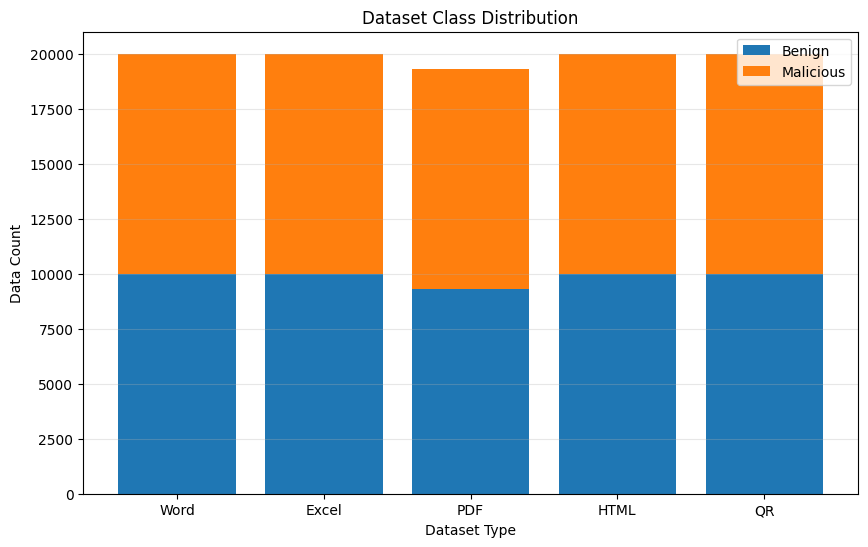

In [13]:
import matplotlib.pyplot as plt

datasets = {
    "Word": df_word,
    "Excel": df_excel,
    "PDF": df_pdf,
    "HTML": df_html,
    "QR": df_qr
}

benign_counts = []
malicious_counts = []
names = []

for name, df in datasets.items():
    names.append(name)
    benign_counts.append((df["label"] == 0).sum())
    malicious_counts.append((df["label"] == 1).sum())

x = range(len(names))

plt.figure(figsize=(10,6))

plt.bar(x, benign_counts, label="Benign")
plt.bar(x, malicious_counts, bottom=benign_counts, label="Malicious")

plt.xticks(x, names)
plt.title("Dataset Class Distribution")
plt.xlabel("Dataset Type")
plt.ylabel("Data Count")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

QR Feature Extraction

In [ ]:
import pandas as pd

def load_qr_dataset(qr_balanced):

    qr_df = pd.read_csv(qr_balanced)

    # keep only needed columns
    df = qr_df[["url", "label"]]

    return df

In [ ]:
import re
import math
from urllib.parse import urlparse
from collections import Counter


# ----------------------------
# 1. ENTROPY
# ----------------------------
def entropy(text):
    if len(text) == 0:
        return 0

    probs = [c / len(text) for c in Counter(text).values()]
    return -sum(p * math.log2(p) for p in probs)


# ----------------------------
# 2. URL PARSING SAFELY
# ----------------------------
def safe_parse(url):
    try:
        url = str(url).strip()

        if url == "" or url.lower() == "nan":
            return urlparse("http://empty.local")

        # ensure scheme exists
        if not url.startswith(("http://", "https://")):
            url = "http://" + url

        # final safety parse
        return urlparse(url)

    except Exception:
        # fallback for ANY malformed URL (including IPv6 issues)
        return urlparse("http://invalid.local")


# ----------------------------
# 3. FEATURE EXTRACTOR
# ----------------------------
def extract_features(url):

    url = str(url).lower()
    parsed = safe_parse(url)

    return {
        # LENGTH
        "url_length": len(url),

        # ENTROPY (obfuscation)
        "entropy": entropy(url),

        # STRUCTURE
        "subdomain_count": parsed.netloc.count("."),
        "path_depth": parsed.path.count("/"),

        # NUMERIC PATTERNS
        "digit_ratio": sum(c.isdigit() for c in url) / (len(url) + 1),

        # SPECIAL CHARACTERS
        "special_char_ratio": len(re.findall(r"[^a-zA-Z0-9]", url)) / (len(url) + 1),

        # HOST ANOMALY
        "has_ip": int(bool(re.search(r"\d+\.\d+\.\d+\.\d+", url))),

        # PHISHING INTENT
        "keyword_score": sum(
            k in url for k in [
                "login", "verify", "secure", "account",
                "bank", "update", "password", "signin"
            ]
        )
    }

In [ ]:
import pandas as pd


def build_dataset(df):

    X = []
    y = []

    invalid_urls = 0

    for _, row in df.iterrows():

        url = row["url"]
        label = row["label"]

        features = extract_features(url)

        # safety check
        if features["url_length"] == 0:
            invalid_urls += 1
            continue

        X.append(features)
        y.append(label)

    X = pd.DataFrame(X)

    print(f"[INFO] Invalid URLs skipped: {invalid_urls}")

    return X, y

In [ ]:
def save_features(df, output_path):

    X, y = build_dataset(df)

    X["label"] = y

    X.to_csv(output_path, index=False)

    print(f"[INFO] Saved feature dataset → {output_path}")

In [ ]:
save_features(load_qr_dataset("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_balanced.csv"), "/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_features.csv")

[INFO] Invalid URLs skipped: 0
[INFO] Saved feature dataset → /content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_features.csv


In [ ]:
df_qr_balanced = pd.read_csv("/content/drive/MyDrive/AdaptivePhishingDetection/Trap4PhishDataset/qr_features.csv")

In [ ]:
df_qr_balanced.tail()

,url_length,entropy,subdomain_count,path_depth,digit_ratio,special_char_ratio,has_ip,keyword_score,label
19995,211,5.010672,1,7,0.202830,0.113208,0,0,1
19996,22,3.845351,1,1,0.173913,0.217391,0,0,1
19997,45,4.311422,2,4,0.152174,0.173913,0,0,0
19998,26,3.825252,2,2,0.037037,0.185185,0,0,0
19999,18,2.885513,3,0,0.736842,0.210526,1,0,1


In [ ]:
df_qr_balanced.count()

,0
url_length,20000
entropy,20000
subdomain_count,20000
path_depth,20000
digit_ratio,20000
special_char_ratio,20000
has_ip,20000
keyword_score,20000
label,20000


In [ ]:
FEATURE_SCHEMA = [

    # =====================
    # GENERIC STATISTICAL FEATURES
    # =====================
    "file_size",
    "entropy",

    # =====================
    # STRUCTURAL FEATURES (ALL MODALITIES)
    # =====================
    "token_count",
    "special_char_ratio",
    "digit_ratio",
    "avg_token_length",

    # =====================
    # HTML / SCRIPT BEHAVIOR
    # =====================
    "tag_count",
    "script_count",
    "form_count",
    "external_link_count",

    # =====================
    # OFFICE BEHAVIOR
    # =====================
    "macro_present",
    "macro_keyword_score",

    # =====================
    # PDF STRUCTURE
    # =====================
    "pdf_stream_count",
    "pdf_metadata_size",

    # =====================
    # URL / QR FEATURES (CLEAN VERSION)
    # =====================
    "url_length",
    "subdomain_count",
    "path_depth",
    "has_ip",
    "keyword_score"
]

In [ ]:
def to_unified(row, dataset_type):

    x = dict.fromkeys(FEATURE_SCHEMA, 0)

    # =====================
    # HTML
    # =====================
    if dataset_type == "html":

        x["entropy"] = row.get("entropy", 0)
        x["tag_count"] = row.get("tag_count", 0)
        x["form_count"] = row.get("form_count", 0)
        x["embedded_js_count"] = row.get("embedded_js_count", 0)
        x["external_link_count"] = row.get("external_link_count", 0)


    # =====================
    # WORD
    # =====================
    elif dataset_type == "word":

        x["entropy"] = row.get("entropy", 0)
        x["file_size"] = row.get("file_size", 0)

        x["macro_present"] = row.get("macro_present", 0)
        x["macro_keyword_score"] = row.get("vba_keywords_count", 0)


    # =====================
    # EXCEL
    # =====================
    elif dataset_type == "excel":

        x["entropy"] = row.get("entropy_of_text", 0)
        x["file_size"] = row.get("file_size", 0)

        x["macro_keyword_score"] = row.get("macro_token_count", 0)


    # =====================
    # PDF
    # =====================
    elif dataset_type == "pdf":

        x["entropy"] = row.get("entropy_of_streams", 0)
        x["file_size"] = row.get("file_size", 0)

        x["pdf_stream_count"] = row.get("stream_count", 0)
        x["pdf_metadata_size"] = row.get("metadata_size", 0)


    # =====================
    # QR (NOW USING PRECOMPUTED CSV)
    # =====================
    elif dataset_type == "qr":

        # DIRECT MAPPING FROM qr_features.csv
        x["url_length"] = row.get("url_length", 0)
        x["entropy"] = row.get("entropy", 0)

        x["subdomain_count"] = row.get("subdomain_count", 0)
        x["path_depth"] = row.get("path_depth", 0)

        x["digit_ratio"] = row.get("digit_ratio", 0)
        x["special_char_ratio"] = row.get("special_char_ratio", 0)

        x["has_ip"] = row.get("has_ip", 0)
        x["keyword_score"] = row.get("keyword_score", 0)


    return x

In [ ]:
word_rows = df_word.to_dict("records")
excel_rows = df_excel.to_dict("records")
pdf_rows = df_pdf.to_dict("records")
html_rows = df_html.to_dict("records")
qr_rows = df_qr_balanced.to_dict("records")

In [ ]:
word_stream = [
    (to_unified(r, "word"), r["label"], "word")
    for r in word_rows
]

excel_stream = [
    (to_unified(r, "excel"), r["label"], "excel")
    for r in excel_rows
]

pdf_stream = [
    (to_unified(r, "pdf"), r["label"], "pdf")
    for r in pdf_rows
]

html_stream = [
    (to_unified(r, "html"), r["label"], "html")
    for r in html_rows
]

qr_stream = [
    (to_unified(r, "qr"), r["label"], "qr")
    for r in qr_rows
]

In [ ]:
import random

stream = word_stream + excel_stream + pdf_stream + html_stream + qr_stream
#random.shuffle(full_stream)

In [ ]:
from river.forest import ARFClassifier
from river.tree import HoeffdingTreeClassifier, HoeffdingAdaptiveTreeClassifier
from river.linear_model import LogisticRegression
from river.drift import ADWIN, KSWIN, PageHinkley
from river import metrics

In [ ]:
from river import metrics

def stream_evaluate(model, stream, drift_detector=None):

    word_end=20000
    excel_end=40000
    pdf_end=59296
    html_end=79293
    qr_end=99293

    acc = metrics.Accuracy()
    prec = metrics.Precision()
    rec = metrics.Recall()
    f1 = metrics.F1()

    accuracy_curve = []
    precision_curve = []
    recall_curve = []
    f1_curve = []

    drift_points = []

    stable_points = []
    sub_drift_points = []
    hard_drift_points = []
    extreme_drift_points = []

    for i, (x, y, dataset_type) in enumerate(stream):

        y_pred = model.predict_one(x)

        if y_pred is not None:

            acc.update(y, y_pred)
            prec.update(y, y_pred)
            rec.update(y, y_pred)
            f1.update(y, y_pred)


            # optional drift detector update
            if drift_detector is not None:
                error = int(y_pred != y)
                drift_detector.update(error)

                # -------------------------
                # DRIFT TYPE CLASSIFICATION
                # -------------------------
                if i < word_end:

                    drift_type = "STABLE"
                    stable_points.append(i)

                elif i < excel_end:

                    drift_type = "SUB DRIFT (Word → Excel)"
                    sub_drift_points.append(i)

                elif i < pdf_end:

                    drift_type = "SUB DRIFT (Excel → PDF)"
                    sub_drift_points.append(i)

                elif i < html_end:

                    drift_type = "HARD DRIFT (PDF → HTML)"
                    hard_drift_points.append(i)

                elif i < qr_end:

                    drift_type = "EXTREME DRIFT (HTML → QR)"
                    extreme_drift_points.append(i)

                if drift_detector.drift_detected:
                    drift_points.append({
                        "step": i,
                        "drift_type": drift_type,
                        "accuracy": acc.get(),
                        "f1": f1.get()
                    })

        model.learn_one(x, y)

        accuracy_curve.append(acc.get())
        precision_curve.append(prec.get())
        recall_curve.append(rec.get())
        f1_curve.append(f1.get())

    return {
        "accuracy": accuracy_curve,
        "precision": precision_curve,
        "recall": recall_curve,
        "f1": f1_curve,
        "drift_points": drift_points,
        "stable_points": stable_points,
        "sub_drift_points": sub_drift_points,
        "hard_drift_points": hard_drift_points,
        "extreme_drift_points": extreme_drift_points
    }

In [ ]:
print(len(stream))

99293


# Models

In [ ]:
lr = LogisticRegression()

In [ ]:
arf = ARFClassifier(seed=42)

In [ ]:
ht = HoeffdingTreeClassifier()

In [ ]:
hat = HoeffdingAdaptiveTreeClassifier()

In [ ]:
adwin = ADWIN()

In [ ]:
kswin = KSWIN(alpha=0.001)

In [ ]:
ph = PageHinkley()

In [ ]:
lr_results = stream_evaluate(
    lr,
    stream,
    drift_detector=None
)

In [ ]:
arf = ARFClassifier(seed=42)

arf_adwin_results = stream_evaluate(
    arf,
    stream,
    drift_detector=adwin
)

In [ ]:
arf_kswin_results= stream_evaluate(
    arf,
    stream,
    drift_detector=kswin
)

In [ ]:
arf_ph_results = stream_evaluate(
    arf,
    stream,
    drift_detector=ph
)

In [ ]:
ht_adwin_results = stream_evaluate(
    ht,
    stream,
    drift_detector=adwin
)

In [ ]:
ht_kswin_results = stream_evaluate(
    ht,
    stream,
    drift_detector=kswin
)

In [ ]:
ht_ph_results = stream_evaluate(
    ht,
    stream,
    drift_detector=ph
)

In [ ]:
hat_adwin_results = stream_evaluate(
    hat,
    stream,
    drift_detector=adwin
)

In [ ]:
hat_kswin_results = stream_evaluate(
    hat,
    stream,
    drift_detector=kswin
)

In [ ]:
hat_ph_results = stream_evaluate(
    hat,
    stream,
    drift_detector=ph
)

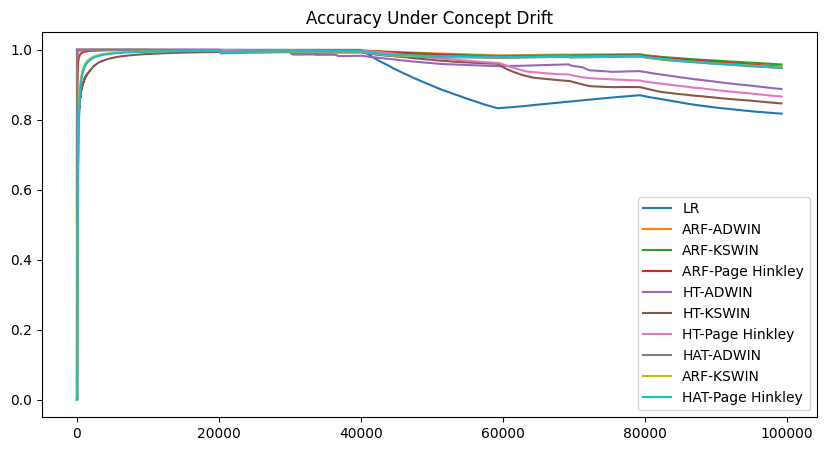

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(lr_results["accuracy"], label="LR")
plt.plot(arf_adwin_results["accuracy"], label="ARF-ADWIN")
plt.plot(arf_kswin_results["accuracy"], label="ARF-KSWIN")
plt.plot(arf_ph_results["accuracy"], label="ARF-Page Hinkley")
plt.plot(ht_adwin_results["accuracy"], label="HT-ADWIN")
plt.plot(ht_kswin_results["accuracy"], label="HT-KSWIN")
plt.plot(ht_ph_results["accuracy"], label="HT-Page Hinkley")
plt.plot(hat_adwin_results["accuracy"], label="HAT-ADWIN")
plt.plot(hat_kswin_results["accuracy"], label="ARF-KSWIN")
plt.plot(hat_ph_results["accuracy"], label="HAT-Page Hinkley")

plt.title("Accuracy Under Concept Drift")
plt.legend()
plt.show()

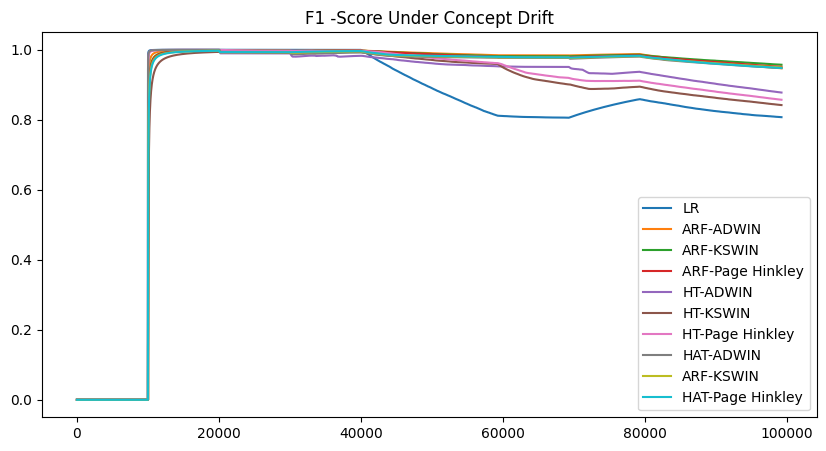

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(lr_results["f1"], label="LR")
plt.plot(arf_adwin_results["f1"], label="ARF-ADWIN")
plt.plot(arf_kswin_results["f1"], label="ARF-KSWIN")
plt.plot(arf_ph_results["f1"], label="ARF-Page Hinkley")
plt.plot(ht_adwin_results["f1"], label="HT-ADWIN")
plt.plot(ht_kswin_results["f1"], label="HT-KSWIN")
plt.plot(ht_ph_results["f1"], label="HT-Page Hinkley")
plt.plot(hat_adwin_results["f1"], label="HAT-ADWIN")
plt.plot(hat_kswin_results["f1"], label="ARF-KSWIN")
plt.plot(hat_ph_results["f1"], label="HAT-Page Hinkley")

plt.title("F1 -Score Under Concept Drift")
plt.legend()
plt.show()

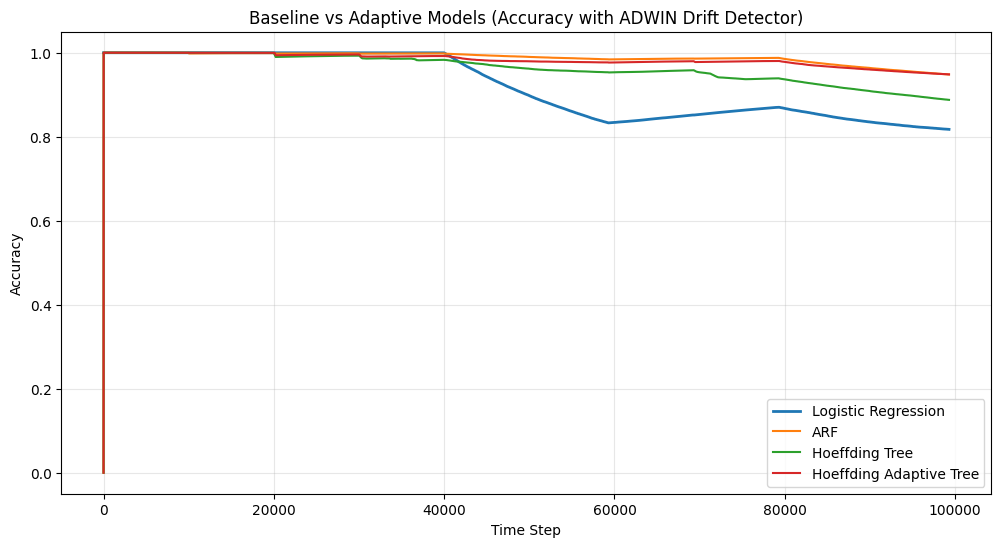

In [ ]:
plt.figure(figsize=(12,6))

# Baseline
plt.plot(lr_results["accuracy"], label="Logistic Regression", linewidth=2)

# Adaptive models
plt.plot(arf_adwin_results["accuracy"], label="ARF")
plt.plot(ht_adwin_results["accuracy"], label="Hoeffding Tree")
plt.plot(hat_adwin_results["accuracy"], label="Hoeffding Adaptive Tree")

plt.title("Baseline vs Adaptive Models (Accuracy with ADWIN Drift Detector)")
plt.xlabel("Time Step")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

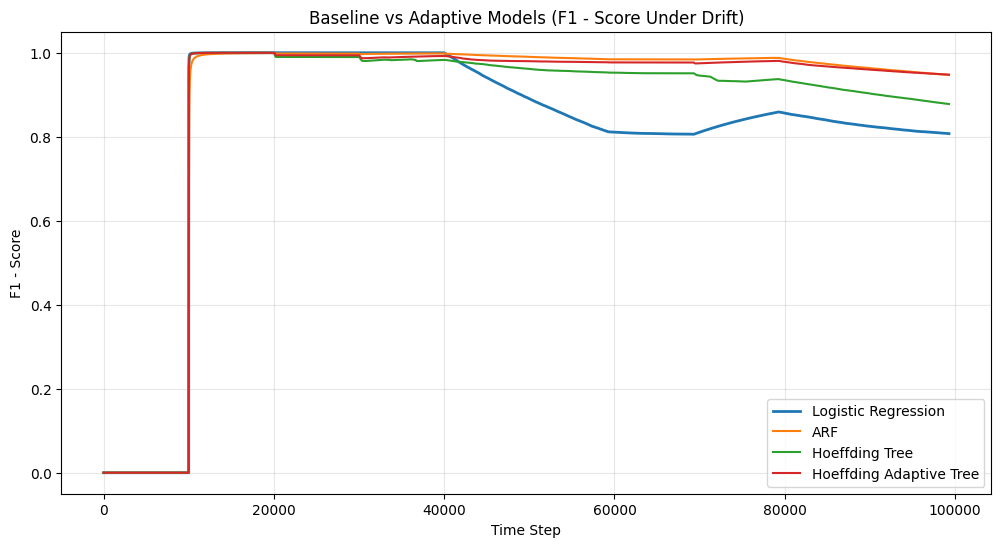

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Baseline
plt.plot(lr_results["f1"], label="Logistic Regression", linewidth=2)

# Adaptive models
plt.plot(arf_adwin_results["f1"], label="ARF")
plt.plot(ht_adwin_results["f1"], label="Hoeffding Tree")
plt.plot(hat_adwin_results["f1"], label="Hoeffding Adaptive Tree")

plt.title("Baseline vs Adaptive Models (F1 - Score Under Drift)")
plt.xlabel("Time Step")
plt.ylabel("F1 - Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

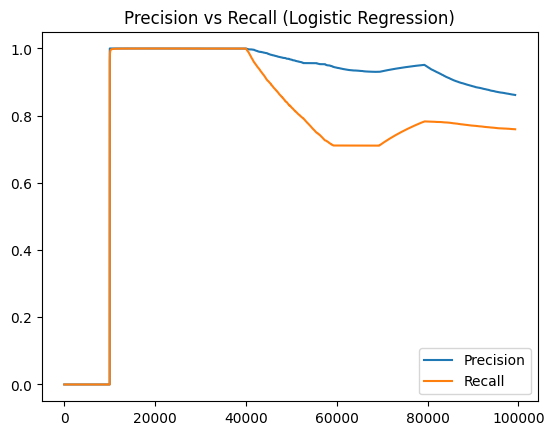

In [ ]:
plt.plot(lr_results["precision"], label="Precision")
plt.plot(lr_results["recall"], label="Recall")

plt.title("Precision vs Recall (Logistic Regression)")
plt.legend()
plt.show()

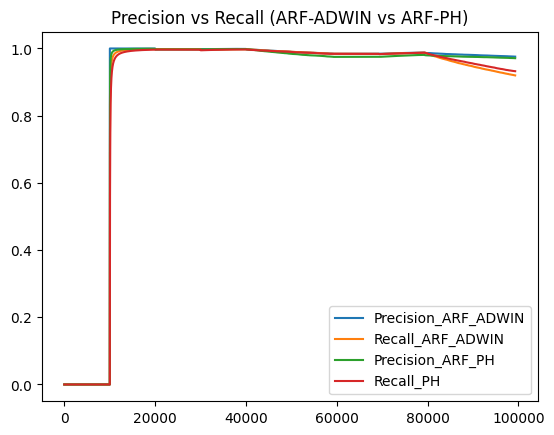

In [ ]:
plt.plot(arf_adwin_results["precision"], label="Precision_ARF_ADWIN")
plt.plot(arf_adwin_results["recall"], label="Recall_ARF_ADWIN")

plt.plot(arf_ph_results["precision"], label="Precision_ARF_PH")
plt.plot(arf_ph_results["recall"], label="Recall_PH")

plt.title("Precision vs Recall (ARF-ADWIN vs ARF-PH)")
plt.legend()
plt.show()

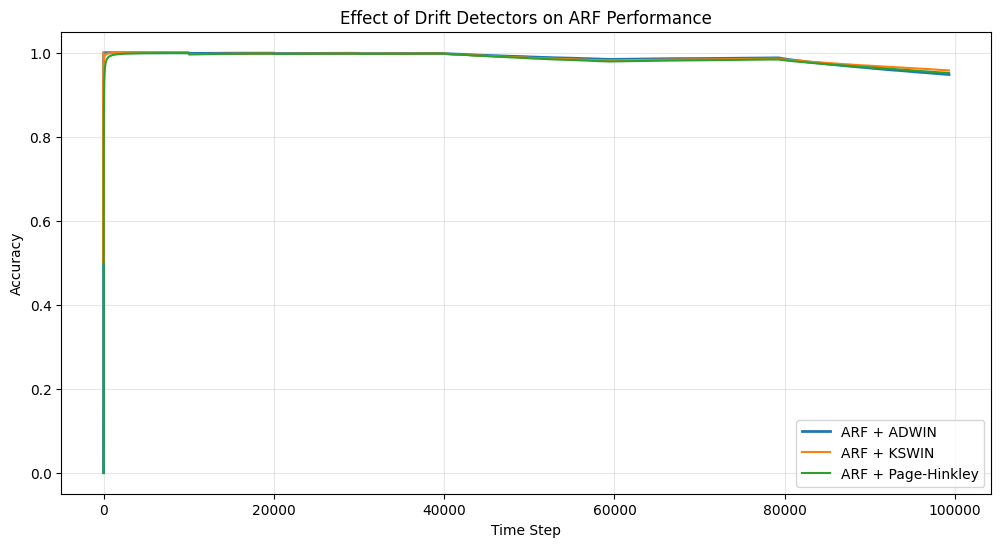

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(arf_adwin_results["accuracy"], label="ARF + ADWIN", linewidth=2)
plt.plot(arf_kswin_results["accuracy"], label="ARF + KSWIN")
plt.plot(arf_ph_results["accuracy"], label="ARF + Page-Hinkley")

plt.title("Effect of Drift Detectors on ARF Performance")
plt.xlabel("Zaman")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

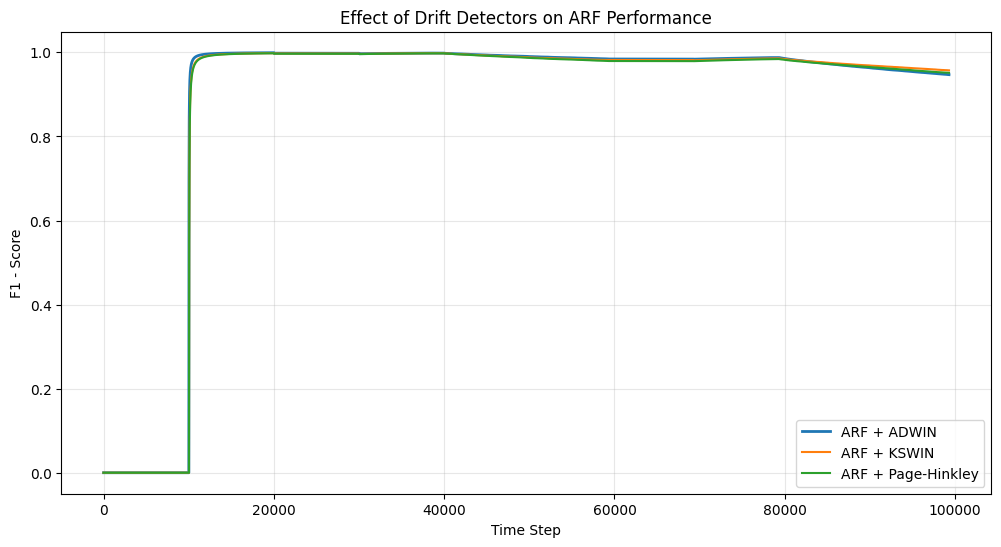

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(arf_adwin_results["f1"], label="ARF + ADWIN", linewidth=2)
plt.plot(arf_kswin_results["f1"], label="ARF + KSWIN")
plt.plot(arf_ph_results["f1"], label="ARF + Page-Hinkley")

plt.title("Effect of Drift Detectors on ARF Performance")
plt.xlabel("Time Step")
plt.ylabel("F1 - Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

RF To Reveal Noise In Datasets Analysis

In [ ]:
import pandas as pd
import numpy as np

def analyze_label_noise(model, X, y, dataset_type=None):

    results = []

    predictions = model.predict(X)

    for i in range(len(X)):

        true_label = y.iloc[i] if hasattr(y, "iloc") else y[i]
        pred_label = predictions[i]

        results.append({
            "true_label": true_label,
            "pred_label": pred_label,
            "is_noisy": int(true_label != pred_label),
            "dataset_type": dataset_type
        })

    df = pd.DataFrame(results)

    return df

In [ ]:
def noise_summary(df):

    total = len(df)
    noisy = df["is_noisy"].sum()

    print("Total samples:", total)
    print("Noisy samples:", noisy)
    print("Noise ratio:", noisy / total)

    return {
        "total": total,
        "noisy": noisy,
        "noise_ratio": noisy / total
    }

In [ ]:
def classwise_noise(df):

    summary = df.groupby("true_label")["is_noisy"].mean()

    print("\nClass-wise noise rate:")
    print(summary)

    return summary

In [ ]:
def modality_noise(df):

    summary = df.groupby("dataset_type")["is_noisy"].mean()

    print("\nModality-wise noise rate:")
    print(summary)

    return summary

In [ ]:
import matplotlib.pyplot as plt

def plot_noise(modality_summary):

    modality_summary.plot(kind="bar")

    plt.title("Label Noise by Modality")
    plt.ylabel("Noise Ratio")
    plt.xlabel("Dataset Type")

    plt.show()

Total samples: 29788
Noisy samples: 749
Noise ratio: 0.025144353430911776

Class-wise noise rate:
true_label
0    0.021811
1    0.030086
Name: is_noisy, dtype: float64

Modality-wise noise rate:
dataset_type
qr    0.025144
Name: is_noisy, dtype: float64


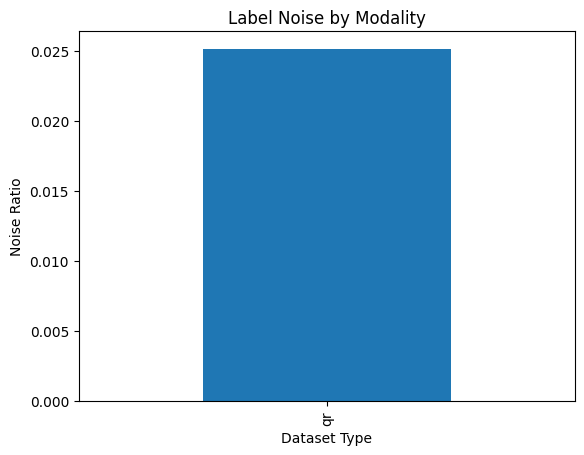

In [ ]:
df_results = analyze_label_noise(rf, X_test, y_test, dataset_type="qr")

summary = noise_summary(df_results)
classwise = classwise_noise(df_results)
modality = modality_noise(df_results)

plot_noise(modality)